## Model Evaluation

### Setup

In [3]:
# Standard Libraries
import os
import gc
import math
import json
import datetime
from pathlib import Path
import multiprocessing

# Data Handling
import numpy as np
import pandas as pd
import nibabel as nib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Image & Augmentation
import cv2
import albumentations as alb

# Machine Learning & PyTorch
import torch
from torchmetrics import Accuracy, Precision, Recall, F1Score, ConfusionMatrix
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from torchvision.transforms import transforms
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

# MONAI - Medical Imaging
from monai.networks.nets import UNETR, UNet
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.utils import one_hot
from monai.transforms import AsDiscrete
from monai.data import decollate_batch
from monai.losses import DiceLoss, DiceCELoss, HausdorffDTLoss
from monai.metrics import DiceMetric
from monai.visualize import GradCAM

# Privacy & Logging
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import wandb

In [4]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data

In [5]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [6]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (1000, 6)
Validation set shape: (125, 6)
Test set shape: (126, 6)


### Custom Dataset Class

In [7]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

In [8]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})

In [9]:
# Adversarial Transformations
from albumentations import Compose, GaussNoise, MotionBlur, GridDistortion, RandomBrightnessContrast, ImageCompression

adversarial_like_intensity = Compose([
    GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    MotionBlur(blur_limit=3, p=0.3),
    GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
    RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
    ImageCompression(quality_lower=20, quality_upper=70, p=0.3),
])

adversarial_transformations = {
    "spatial_transforms": val_spatial_transforms,
    "intensity_transforms": adversarial_like_intensity
}

/tmp/ipykernel_4174272/3888069531.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/tmp/ipykernel_4174272/3888069531.py:9: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  ImageCompression(quality_lower=20, quality_upper=70, p=0.3),


In [10]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=None)
test_adv_data = BrainTumorDataset(dataset_test,
                                  upper_bound=upper_bound,
                                  lower_bound=lower_bound,
                                  window_size = window_size,
                                  transformations=adversarial_transformations)
pd.Series({
    'Test dataset size:': len(test_data),
}).to_frame().style.hide(axis='columns')

Test dataset size:,126


In [11]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = 3
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
test_dataloader = DataLoader(test_data, **data_loader_params)
test_adv_dataloader = DataLoader(test_adv_data, **data_loader_params)

Number of datapoints per batch 80


In [12]:
pd.Series({
    'Number of batches in test dataLoader:': len(test_dataloader),
}).to_frame().style.hide(axis='columns')

Number of batches in test dataLoader:,63


In [44]:
for batch_idx, (data, mask) in enumerate(test_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


### Model

In [13]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [13]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-03-27_11-46-28/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


### Evaluation

In [14]:
def release_cuda_memory():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

In [59]:
num_classes = 4
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
f1_score = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

In [27]:
def no_grad_fgsm_attack(model, data, mask, epsilon):

    batch_size, modality, h, w = data.shape

    data = data.view(batch_size, modality, h, w).clone().detach().to(device)
    data.requires_grad = True  # Set requires_grad only for FGSM, not the model

    # Disable gradients on model parameters
    for param in model.parameters():
        param.requires_grad = False

    # Generate output of data and loss
    output = model(data)
    loss = torch.nn.functional.cross_entropy(output, mask.long())

    # Compute gradients (only for perturbation)
    grad = torch.autograd.grad(loss, data, retain_graph=False, create_graph=False)[0]

    # Generate perturbed data
    perturbation = epsilon * grad.sign()
    adv_data = data + perturbation
    adv_data = torch.clamp(adv_data, 0, 1)  # Keep pixel values in range [0, 1]

    return adv_data

### Base Model Evaluation

In [17]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [18]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.994050
Precision,0.893865
Recall,0.895307
F1 Score,0.894494
Dice Score,0.773027


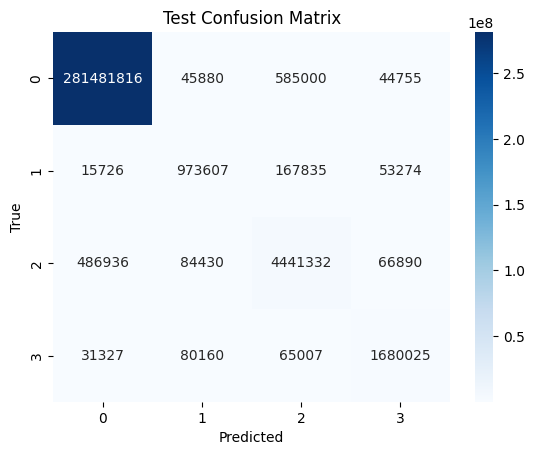

In [19]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [20]:
base_model_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

#### Robustness Evaluation - With Transforms

In [21]:
model.eval()
for batch_id, (data, masks) in enumerate(test_adv_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [22]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.974299
Precision,0.805552
Recall,0.326152
F1 Score,0.381117
Dice Score,0.086091


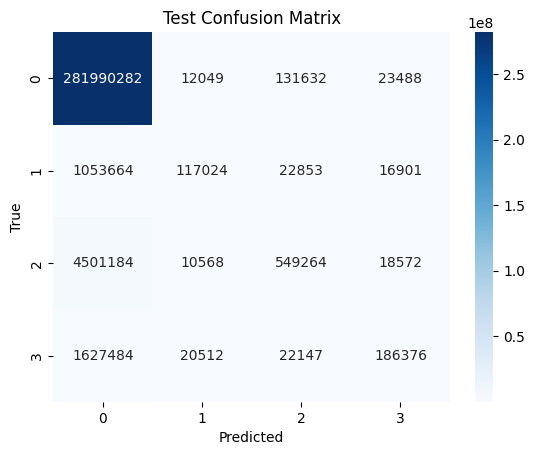

In [23]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [24]:
base_model_transforms_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

#### Robustness Evaluation - With Gradient Loss

In [25]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    data_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds_adversarial = model(data_adversarial)
        preds_adversarial = torch.argmax(preds_adversarial, dim=1)
        accuracy.update(preds_adversarial, masks)
        precision.update(preds_adversarial, masks)
        recall.update(preds_adversarial, masks)
        f1_score.update(preds_adversarial, masks)
        confusion_matrix.update(preds_adversarial, masks)
        dice_metric(
            y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [26]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.971903
Precision,0.243952
Recall,0.249993
F1 Score,0.246444
Dice Score,0.000003


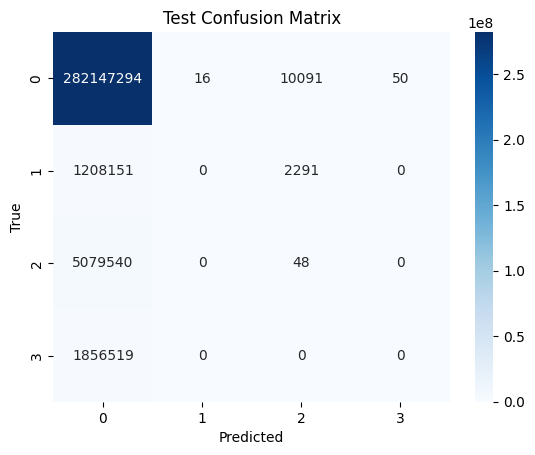

In [27]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [28]:
base_model_gradient_loss_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### Overall Performance (Both Clean and Adversarial Data)

In [30]:
model.eval()

# Hyperparameter for type of adversarial test generation:
transforms_adv = False

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    adv_data = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = model(adv_data)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [31]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.982977
Precision,0.890043
Recall,0.572650
F1 Score,0.678025
Dice Score,0.386515


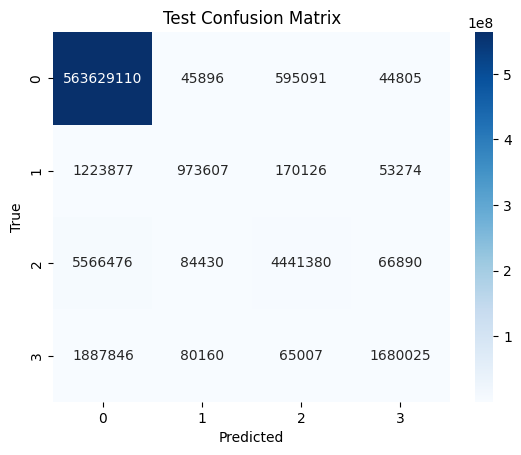

In [32]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [33]:
base_model_overall_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

##### Compilation

In [35]:
pd.DataFrame({'Baseline':base_model_metrics, 
              'Robustness - Transforms':base_model_transforms_metrics,
             'Robustness - Gradient Loss':base_model_gradient_loss_metrics,
             'Overall': base_model_overall_metrics}).T

,Accuracy,Precision,Recall,F1 Score,Dice Score
Baseline,0.994050,0.893865,0.895307,0.894494,0.773027
Robustness - Transforms,0.974299,0.805552,0.326152,0.381117,0.086091
Robustness - Gradient Loss,0.971903,0.243952,0.249993,0.246444,0.000003
Overall,0.982977,0.890043,0.572650,0.678025,0.386515


## Base Model Evaluation with Stochastic Ensembling

We re-enable dropout during inference time to effectively create an ensemble of models with different neurons activated. Then we evaluate each model on the data and average together the predictions to increase performance at ionference time.

In [43]:
# Enable dropout
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()

In [44]:
model.eval()
enable_dropout(model)
num_se_passes = 10

softmax = torch.nn.Softmax(dim=1)

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)

    se_preds = []

    with torch.no_grad():
        for _ in range(num_se_passes):
            out = model(data)
            probs = softmax(out)
            se_preds.append(probs)
    se_preds = torch.stack(se_preds)
    avg_preds = se_preds.mean(dim=0)
    preds = torch.argmax(avg_preds, dim=1)

    accuracy.update(preds, masks)
    precision.update(preds, masks)
    recall.update(preds, masks)
    f1_score.update(preds, masks)
    confusion_matrix.update(preds, masks)
    dice_metric(
        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
    )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [45]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.994339
Precision,0.922597
Recall,0.873799
F1 Score,0.897182
Dice Score,0.763603


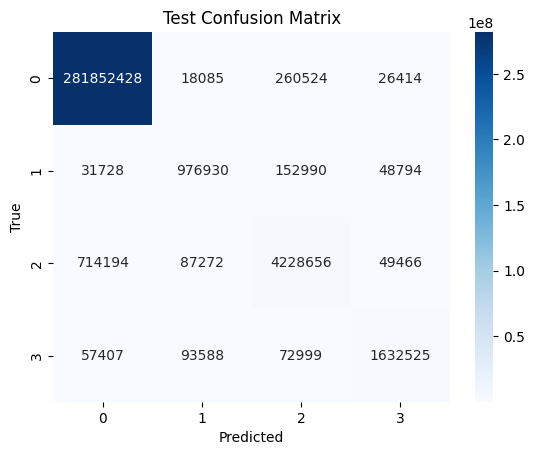

In [38]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

## Adversarial Model Evaluation (Epsilon = 0.1)

In [63]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-04-12_19-52-28/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
seed = 42
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


In [ ]:
num_classes = 4
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
f1_score = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

### On Clean Data

In [64]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [65]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.989394
Precision,0.849860
Recall,0.734778
F1 Score,0.784335
Dice Score,0.626430


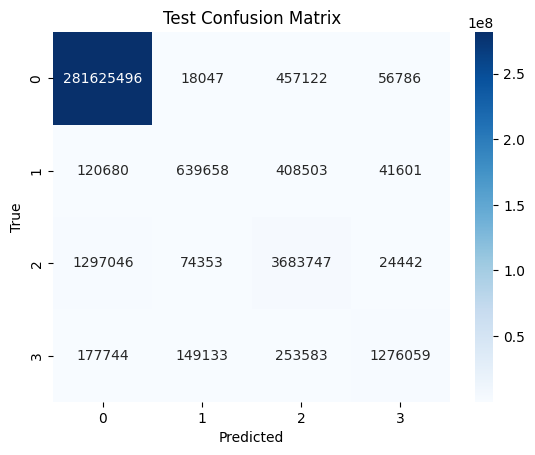

In [66]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [67]:
adv_model_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### With Transforms

In [68]:
model.eval()
for batch_id, (data, masks) in enumerate(test_adv_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [69]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.973816
Precision,0.746237
Recall,0.305858
F1 Score,0.346264
Dice Score,0.076594


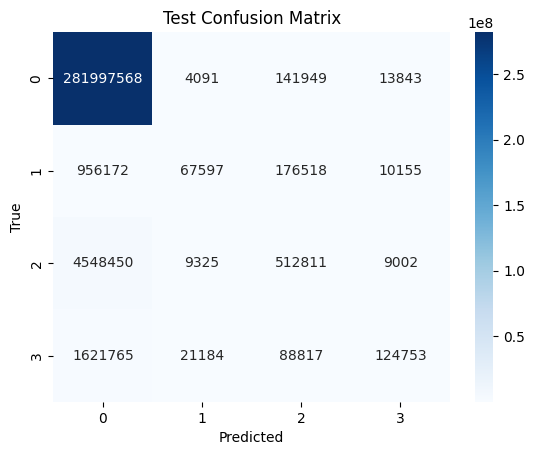

In [70]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [71]:
adv_model_transforms_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### With Gradient Loss

In [72]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    data_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds_adversarial = model(data_adversarial)
        preds_adversarial = torch.argmax(preds_adversarial, dim=1)
        accuracy.update(preds_adversarial, masks)
        precision.update(preds_adversarial, masks)
        recall.update(preds_adversarial, masks)
        f1_score.update(preds_adversarial, masks)
        confusion_matrix.update(preds_adversarial, masks)
        dice_metric(
            y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [73]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.972029
Precision,0.293568
Recall,0.252578
F1 Score,0.251480
Dice Score,0.006473


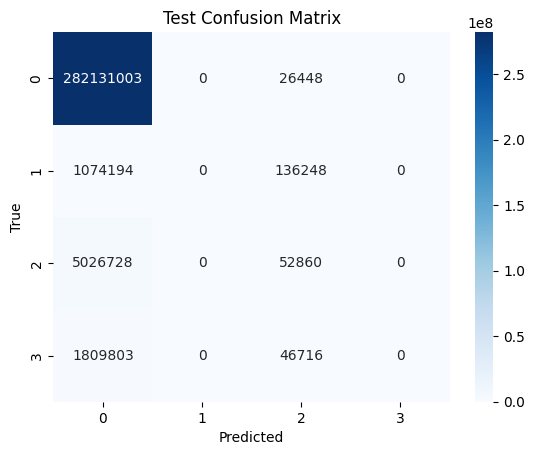

In [74]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [75]:
adv_model_gradient_loss_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [76]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    data_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.3)
    with torch.no_grad():
        preds_adversarial = model(data_adversarial)
        preds_adversarial = torch.argmax(preds_adversarial, dim=1)
        accuracy.update(preds_adversarial, masks)
        precision.update(preds_adversarial, masks)
        recall.update(preds_adversarial, masks)
        f1_score.update(preds_adversarial, masks)
        confusion_matrix.update(preds_adversarial, masks)
        dice_metric(
            y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [77]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.972183
Precision,0.317162
Recall,0.255777
F1 Score,0.257362
Dice Score,0.014049


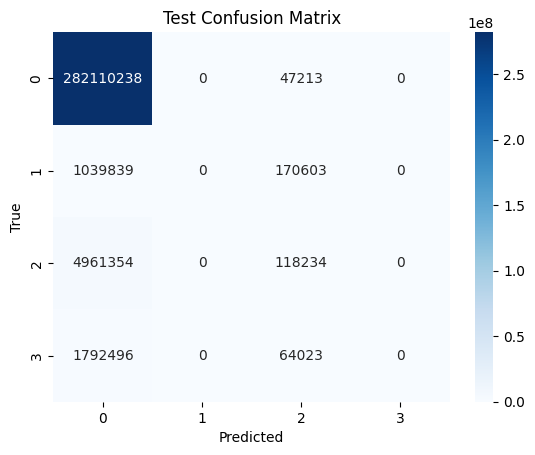

In [78]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [79]:
adv_model_gradient_loss_noisier_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### Overall Performance (Both Clean and Adversarial Data)

In [80]:
model.eval()

# Hyperparameter for type of adversarial test generation:
transforms_adv = False

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    adv_data = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = model(adv_data)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [81]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.980711
Precision,0.839803
Recall,0.493678
F1 Score,0.592175
Dice Score,0.316452


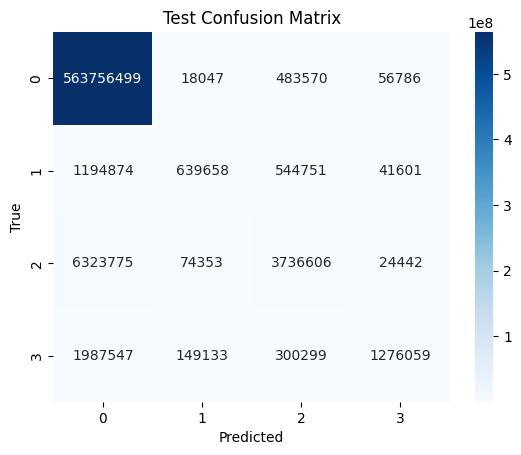

In [82]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [83]:
adv_model_overall_metrics_fgsm = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [84]:
model.eval()

# Hyperparameter for type of adversarial test generation:
transforms_adv = True

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    adv_data = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = model(adv_data)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [85]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.981575
Precision,0.832276
Recall,0.520077
F1 Score,0.616306
Dice Score,0.352511


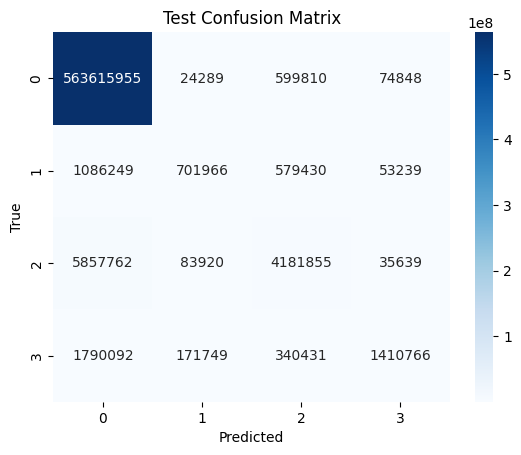

In [86]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [87]:
adv_model_overall_metrics_transform = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [88]:
pd.DataFrame({'Baseline':adv_model_metrics, 
              'Robustness - Transforms':adv_model_transforms_metrics,
              'Robustness - Gradient Loss (Epsilon=0.1)':adv_model_gradient_loss_metrics,
              'Robustness - Gradient Loss (Epsilon=0.3)': adv_model_gradient_loss_noisier_metrics,
              'Overall (Transforms)': adv_model_overall_metrics_fgsm,
              'Overall (FGSM)': adv_model_overall_metrics_transform,
             }).T

,Accuracy,Precision,Recall,F1 Score,Dice Score
Baseline,0.989394,0.849860,0.734778,0.784335,0.626430
Robustness - Transforms,0.973816,0.746237,0.305858,0.346264,0.076594
Robustness - Gradient Loss (Epsilon=0.1),0.972029,0.293568,0.252578,0.251480,0.006473
Robustness - Gradient Loss (Epsilon=0.3),0.972183,0.317162,0.255777,0.257362,0.014049
Overall (Transforms),0.980711,0.839803,0.493678,0.592175,0.316452
Overall (FGSM),0.981575,0.832276,0.520077,0.616306,0.352511


## Adversarial Model Evaluation with Stochastic Ensembling (Epsilon = 0.1)

We re-enable dropout during inference time to effectively create an ensemble of models with different neurons activated. Then we evaluate each model on the data and average together the predictions to increase performance at ionference time.

In [89]:
# Enable dropout
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()

In [90]:
model.eval()
enable_dropout(model)
num_se_passes = 10

softmax = torch.nn.Softmax(dim=1)

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)

    se_preds = []

    with torch.no_grad():
        for _ in range(num_se_passes):
            out = model(data)
            probs = softmax(out)
            se_preds.append(probs)
    se_preds = torch.stack(se_preds)
    avg_preds = se_preds.mean(dim=0)
    preds = torch.argmax(avg_preds, dim=1)

    accuracy.update(preds, masks)
    precision.update(preds, masks)
    recall.update(preds, masks)
    f1_score.update(preds, masks)
    confusion_matrix.update(preds, masks)
    dice_metric(
        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
    )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [91]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.990017
Precision,0.872312
Recall,0.737351
F1 Score,0.790274
Dice Score,0.625890


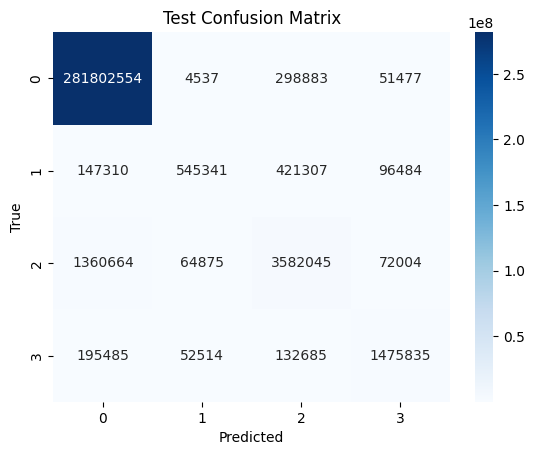

In [92]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

## Adversarial Model Evaluation (Epsilon = 0.3)

In [15]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/2025-04-13_11-22-33/UNET_V0.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNET_V0().to(device)
model.load_state_dict(checkpoint)
num_params = sum(p.numel() for p in model.parameters())
seed = 42
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 494.456K


In [17]:
num_classes = 4
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
precision = Precision(task="multiclass", num_classes=num_classes, average='macro').to(device)
recall = Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
f1_score = F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device)
confusion_matrix = ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

### On Clean Data

In [18]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [19]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.989101
Precision,0.789703
Recall,0.826700
F1 Score,0.806023
Dice Score,0.661196


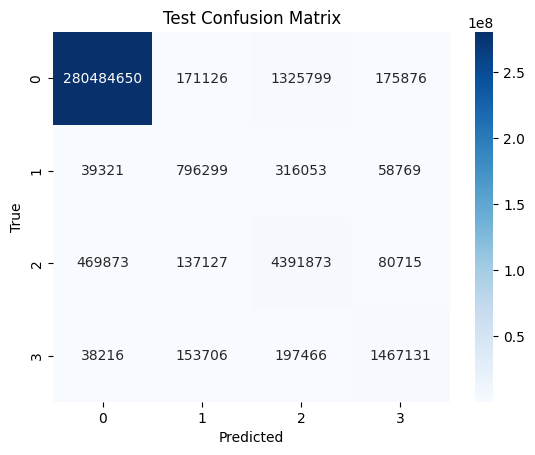

In [20]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [21]:
adv_model_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### With Transforms

In [22]:
model.eval()
for batch_id, (data, masks) in enumerate(test_adv_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [23]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.958898
Precision,0.388044
Recall,0.416024
F1 Score,0.399671
Dice Score,0.176854


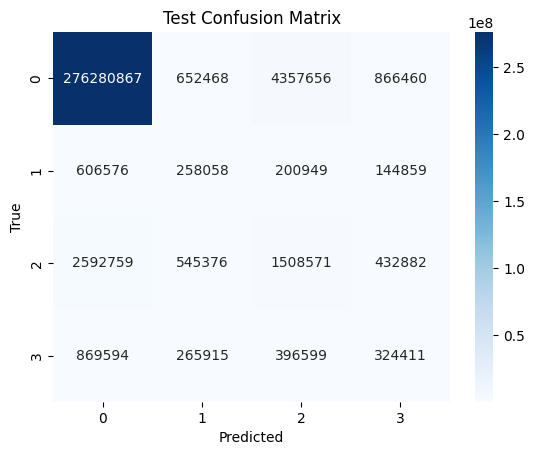

In [24]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [25]:
adv_model_transforms_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### With Gradient Loss

In [28]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    data_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds_adversarial = model(data_adversarial)
        preds_adversarial = torch.argmax(preds_adversarial, dim=1)
        accuracy.update(preds_adversarial, masks)
        precision.update(preds_adversarial, masks)
        recall.update(preds_adversarial, masks)
        f1_score.update(preds_adversarial, masks)
        confusion_matrix.update(preds_adversarial, masks)
        dice_metric(
            y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [29]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.958941
Precision,0.361774
Recall,0.360807
F1 Score,0.360730
Dice Score,0.126307


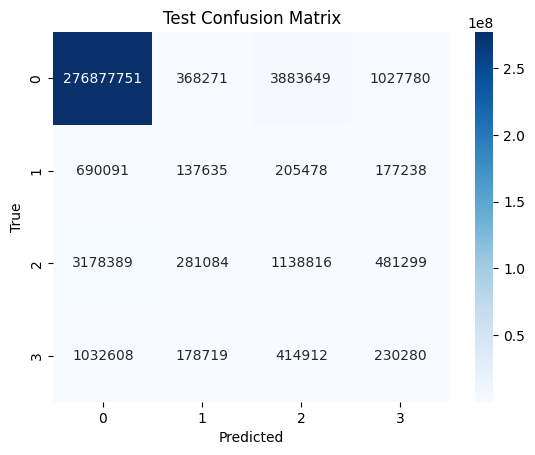

In [30]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [31]:
adv_model_gradient_loss_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [32]:
model.eval()
for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    data_adversarial = no_grad_fgsm_attack(model, data, masks, epsilon=0.3)
    with torch.no_grad():
        preds_adversarial = model(data_adversarial)
        preds_adversarial = torch.argmax(preds_adversarial, dim=1)
        accuracy.update(preds_adversarial, masks)
        precision.update(preds_adversarial, masks)
        recall.update(preds_adversarial, masks)
        f1_score.update(preds_adversarial, masks)
        confusion_matrix.update(preds_adversarial, masks)
        dice_metric(
            y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
        )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [33]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.954100
Precision,0.356239
Recall,0.405831
F1 Score,0.374146
Dice Score,0.148684


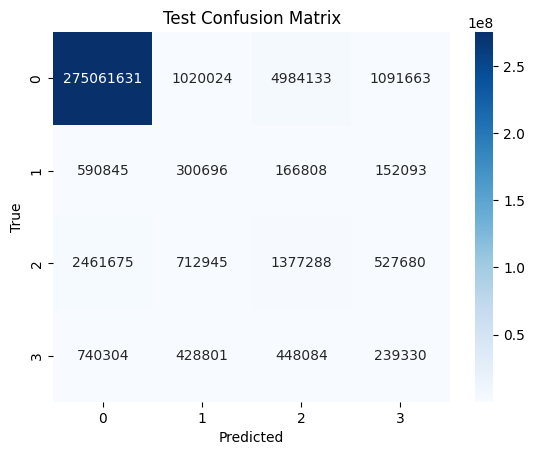

In [34]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [35]:
adv_model_gradient_loss_noisier_metrics = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

### Overall Performance (Both Clean and Adversarial Data)

In [36]:
model.eval()

# Hyperparameter for type of adversarial test generation:
transforms_adv = False

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    adv_data = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = model(adv_data)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [37]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.974021
Precision,0.583728
Recall,0.593754
F1 Score,0.587794
Dice Score,0.393752


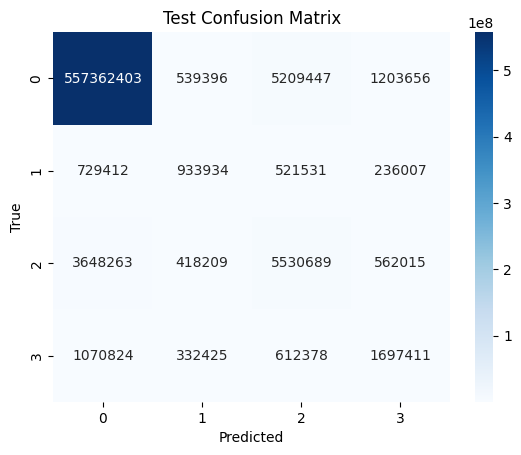

In [38]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [39]:
adv_model_overall_metrics_fgsm = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [40]:
model.eval()

# Hyperparameter for type of adversarial test generation:
transforms_adv = True

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    adv_data = no_grad_fgsm_attack(model, data, masks, epsilon=0.1)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        accuracy.update(preds, masks)
        precision.update(preds, masks)
        recall.update(preds, masks)
        f1_score.update(preds, masks)
        confusion_matrix.update(preds, masks)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
        # Type of adversarial testing to do
        if not transforms_adv:
            preds_adversarial = model(adv_data)
            preds_adversarial = torch.argmax(preds_adversarial, dim=1)
            accuracy.update(preds_adversarial, masks)
            precision.update(preds_adversarial, masks)
            recall.update(preds_adversarial, masks)
            f1_score.update(preds_adversarial, masks)
            confusion_matrix.update(preds_adversarial, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds_adversarial.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

if transforms_adv:
    for batch_id, (data, masks) in enumerate(test_adv_dataloader):
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            preds = torch.argmax(preds, dim=1)
            accuracy.update(preds, masks)
            precision.update(preds, masks)
            recall.update(preds, masks)
            f1_score.update(preds, masks)
            confusion_matrix.update(preds, masks)
            dice_metric(
                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
            )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [41]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.973998
Precision,0.576669
Recall,0.618999
F1 Score,0.594825
Dice Score,0.417843


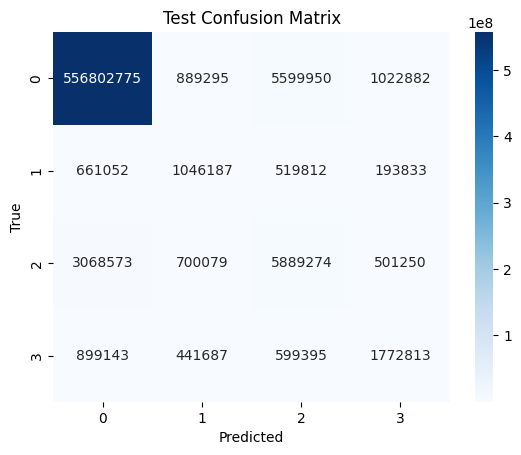

In [42]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [43]:
adv_model_overall_metrics_transform = {
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
    }

In [44]:
pd.DataFrame({'Baseline':adv_model_metrics, 
              'Robustness - Transforms':adv_model_transforms_metrics,
              'Robustness - Gradient Loss (Epsilon=0.1)':adv_model_gradient_loss_metrics,
              'Robustness - Gradient Loss (Epsilon=0.3)': adv_model_gradient_loss_noisier_metrics,
              'Overall (Transforms)': adv_model_overall_metrics_fgsm,
              'Overall (FGSM)': adv_model_overall_metrics_transform,
             }).T

,Accuracy,Precision,Recall,F1 Score,Dice Score
Baseline,0.989101,0.789703,0.826700,0.806023,0.661196
Robustness - Transforms,0.958898,0.388044,0.416024,0.399671,0.176854
Robustness - Gradient Loss (Epsilon=0.1),0.958941,0.361774,0.360807,0.360730,0.126307
Robustness - Gradient Loss (Epsilon=0.3),0.954100,0.356239,0.405831,0.374146,0.148684
Overall (Transforms),0.974021,0.583728,0.593754,0.587794,0.393752
Overall (FGSM),0.973998,0.576669,0.618999,0.594825,0.417843


## Adversarial Model Evaluation with Stochastic Ensembling (Epsilon = 0.3)

We re-enable dropout during inference time to effectively create an ensemble of models with different neurons activated. Then we evaluate each model on the data and average together the predictions to increase performance at ionference time.

In [45]:
# Enable dropout
def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, torch.nn.Dropout):
            m.train()

In [46]:
model.eval()
enable_dropout(model)
num_se_passes = 10

softmax = torch.nn.Softmax(dim=1)

for batch_id, (data, masks) in enumerate(test_dataloader):
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)

    se_preds = []

    with torch.no_grad():
        for _ in range(num_se_passes):
            out = model(data)
            probs = softmax(out)
            se_preds.append(probs)
    se_preds = torch.stack(se_preds)
    avg_preds = se_preds.mean(dim=0)
    preds = torch.argmax(avg_preds, dim=1)

    accuracy.update(preds, masks)
    precision.update(preds, masks)
    recall.update(preds, masks)
    f1_score.update(preds, masks)
    confusion_matrix.update(preds, masks)
    dice_metric(
        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
    )

acc = accuracy.compute().item()
prec = precision.compute().item()
rec = recall.compute().item()
f1 = f1_score.compute().item()
conf_mat = confusion_matrix.compute().cpu().numpy()
dice_score = dice_metric.aggregate().item()

dice_metric.reset()
accuracy.reset()
precision.reset()
recall.reset()
f1_score.reset()
confusion_matrix.reset()
release_cuda_memory()

In [47]:
pd.Series({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1 Score": f1,
    "Dice Score": dice_score
}).to_frame().style.hide(axis='columns')

Accuracy,0.990570
Precision,0.820125
Recall,0.821792
F1 Score,0.819579
Dice Score,0.663494


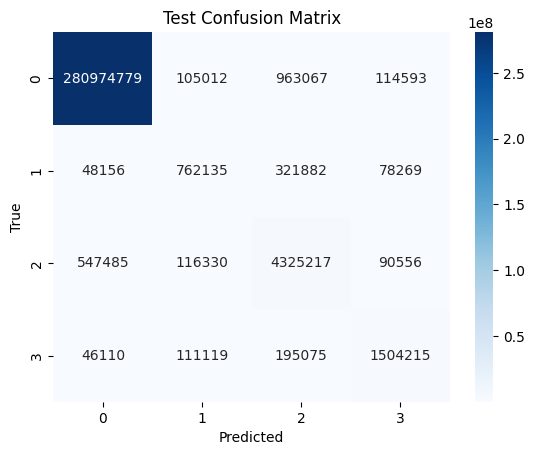

In [48]:
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues", xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()